# Task 1: Data Handling & Memory Management

This notebook demonstrates efficient loading and processing of the ~5 GB (compressed) / ~15 GB (raw) Milan mobile traffic dataset. All optimisation decisions are justified and memory usage is measured before and after each transformation.

## 1.1 Hardware & Software Setup

In [1]:
import platform, os, psutil, zipfile, time
import pandas as pd
import numpy as np

print('=== Hardware & Software Setup ===')
print(f'OS            : {platform.system()} {platform.release()}')
print(f'Python        : {platform.python_version()}')
print(f'Pandas        : {pd.__version__}')
print(f'NumPy         : {np.__version__}')
mem = psutil.virtual_memory()
print(f'Total RAM     : {mem.total / 1e9:.1f} GB')
print(f'Available RAM : {mem.available / 1e9:.1f} GB')
disk = psutil.disk_usage('/')
print(f'Free disk     : {disk.free / 1e9:.1f} GB')
cpu = psutil.cpu_count(logical=True)
print(f'CPU (logical) : {cpu} cores')

=== Hardware & Software Setup ===
OS            : Linux 7.0.3-arch1-2
Python        : 3.14.4
Pandas        : 3.0.3
NumPy         : 2.4.6
Total RAM     : 16.6 GB
Available RAM : 10.3 GB
Free disk     : 245.5 GB
CPU (logical) : 8 cores


## 1.2 Dataset Inventory

In [2]:
DATASET_DIR = '../dataset'
ZIP_FILES = sorted([
    os.path.join(DATASET_DIR, f)
    for f in os.listdir(DATASET_DIR)
    if f.endswith('.zip')
])

total_zip_bytes = 0
total_raw_bytes = 0
all_members = []

for zpath in ZIP_FILES:
    zsize = os.path.getsize(zpath)
    total_zip_bytes += zsize
    with zipfile.ZipFile(zpath) as zf:
        for info in zf.infolist():
            if info.filename.endswith('.txt'):
                total_raw_bytes += info.file_size
                all_members.append((zpath, info.filename, info.file_size))

all_members.sort(key=lambda x: x[1])   # sort by filename (date order)

print(f'Zip files found  : {len(ZIP_FILES)}')
print(f'Daily .txt files : {len(all_members)}')
print(f'Total zip size   : {total_zip_bytes/1e9:.2f} GB')
print(f'Total raw size   : {total_raw_bytes/1e9:.2f} GB')
print(f'\nDate range: {all_members[0][1]} -> {all_members[-1][1]}')

Zip files found  : 7
Daily .txt files : 62
Total zip size   : 5.28 GB
Total raw size   : 20.48 GB

Date range: sms-call-internet-mi-2013-11-01.txt → sms-call-internet-mi-2014-01-01.txt


## 1.3 Column Structure Inspection

From the dataset description [1] (with the corrected field ordering - country code is field 3, not field 5):

| Col | Field               | Needed |
|-----|---------------------|--------|
| 0   | Square id           | ✓      |
| 1   | Time interval (ms)  | ✓      |
| 2   | Country code        |        |
| 3   | SMS activity in     |        |
| 4   | SMS activity out    |        |
| 5   | Call activity in    |        |
| 6   | Call activity out   |        |
| 7   | Internet activity   | ✓      |

In [3]:
# Peek at the first few lines of the first file (read directly from zip)
with zipfile.ZipFile(all_members[0][0]) as zf:
    with zf.open(all_members[0][1]) as f:
        for i, line in enumerate(f):
            print(repr(line.decode('utf-8')))
            if i >= 4:
                break

'1\t1383260400000\t0\t0.08136262351125882\t\t\t\t\n'
'1\t1383260400000\t39\t0.14186425470242922\t0.1567870050390246\t0.16093793691701822\t0.052274848528573205\t11.028366381681026\n'
'1\t1383261000000\t0\t0.13658782275823106\t\t\t0.02730046487718618\t\n'
'1\t1383261000000\t33\t\t\t\t\t0.026137424264286602\n'
'1\t1383261000000\t39\t0.27845207746066025\t0.11992572014174135\t0.1887771729145041\t0.13363747203983203\t11.100963451409388\n'


## 1.4 Memory Measurement Utilities

In [4]:
def mem_used_mb():
    """Return current process RSS in MB."""
    return psutil.Process(os.getpid()).memory_info().rss / 1e6

def df_mem_mb(df):
    """Return DataFrame memory footprint in MB."""
    return df.memory_usage(deep=True).sum() / 1e6

print(f'Baseline process memory: {mem_used_mb():.1f} MB')

Baseline process memory: 161.0 MB


## 1.5 Loading Strategy

### Strategy Overview

**Problem**: 15 GB of raw text, 9.2 GB available RAM.

**Solution - four-layer optimisation**:

1. **Read directly from zip** - Python's `zipfile` module allows streaming decompression without writing anything to disk. This avoids the 15 GB extraction step entirely.
2. **Column selection** (`usecols=[0,1,7]`) - loading only the 3 relevant columns out of 8 reduces the in-memory footprint by ~62% before any other transformation.
3. **Group-sum aggregation** - multiple rows per `(square_id, time_interval)` exist because each country code contributes separately. Summing internet activity per group gives one row per (area, time slot).
4. **Dtype downcasting** - `square_id` -> `int32` (from int64), timestamps -> `int32` after encoding, activity -> `float32` (from float64). Each halves the per-column storage.

The result is a **pivot table** of shape `(T, 10000)` where T is the number of 10-min slots. At float32 this is ~340 MB - easily fits in RAM and is saved as Parquet for fast reuse.

In [5]:
COLS = [0, 1, 7]          # square_id, time_interval_ms, internet_activity
COL_NAMES = ['square_id', 'time_ms', 'internet']
DTYPES = {0: 'int32', 1: 'int64'}   # col 7 (internet) stays float64 during load; downcast after

mem_before_load = mem_used_mb()
print(f'Memory before loading: {mem_before_load:.1f} MB')

t0 = time.time()
chunks = []

for zip_path, member_name, _ in all_members:
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open(member_name) as fobj:
            day_df = pd.read_csv(
                fobj,
                sep='\t',
                header=None,
                usecols=COLS,
                names=COL_NAMES,
                dtype={'square_id': 'int32', 'time_ms': 'int64'},
                na_values=[''],
                low_memory=False
            )
    # Aggregate: one row per (square_id, time_interval)
    day_agg = (
        day_df
        .groupby(['square_id', 'time_ms'], sort=False)['internet']
        .sum()
        .reset_index()
    )
    # Downcast internet to float32
    day_agg['internet'] = day_agg['internet'].astype('float32')
    chunks.append(day_agg)
    print(f'  Loaded {member_name} — {len(day_agg):,} rows', end='\r')

print(f'\nAll files read in {time.time()-t0:.1f}s')
mem_after_load = mem_used_mb()
print(f'Memory after loading chunks: {mem_after_load:.1f} MB')

Memory before loading: 161.1 MB


  Loaded sms-call-internet-mi-2014-01-01.txt — 1,438,701 rows
All files read in 415.2s
Memory after loading chunks: 1837.0 MB


In [6]:
# Concatenate all daily chunks
t1 = time.time()
raw_df = pd.concat(chunks, ignore_index=True)
del chunks   # free per-day list

print(f'Concat done in {time.time()-t1:.1f}s')
print(f'Shape: {raw_df.shape}')
print(f'DataFrame memory (raw): {df_mem_mb(raw_df):.1f} MB')
print(f'Process memory: {mem_used_mb():.1f} MB')
raw_df.head()

Concat done in 1.0s
Shape: (87874021, 3)
DataFrame memory (raw): 1406.0 MB
Process memory: 3243.1 MB


,square_id,time_ms,internet
0,1,1383260400000,11.028366
1,1,1383261000000,11.127101
2,1,1383261600000,10.892771
3,1,1383262200000,8.622424
4,1,1383262800000,8.009928


## 1.6 Timestamp Conversion & Deduplication

In [7]:
# Convert ms timestamp to datetime, then to a compact integer slot index
raw_df['timestamp'] = pd.to_datetime(raw_df['time_ms'], unit='ms', utc=True)
raw_df = raw_df.drop(columns=['time_ms'])

# Some (square_id, timestamp) pairs may still appear twice across files — aggregate again
print('Checking for duplicate (square_id, timestamp) pairs...')
raw_df = raw_df.groupby(['square_id', 'timestamp'], sort=False)['internet'].sum().reset_index()
raw_df['internet'] = raw_df['internet'].astype('float32')

print(f'Unique squares   : {raw_df["square_id"].nunique()}')
print(f'Unique timestamps: {raw_df["timestamp"].nunique()}')
print(f'Total rows       : {len(raw_df):,}')
print(f'DataFrame memory : {df_mem_mb(raw_df):.1f} MB')

Checking for duplicate (square_id, timestamp) pairs...


Unique squares   : 10000


Unique timestamps: 8928
Total rows       : 87,874,021
DataFrame memory : 1406.0 MB


## 1.7 Pivot to Wide Format & Handle Missing Values

In [8]:
# Pivot: rows = timestamps, columns = square_ids
t2 = time.time()
pivot = raw_df.pivot(index='timestamp', columns='square_id', values='internet')
del raw_df

pivot.sort_index(inplace=True)
pivot.columns.name = None

print(f'Pivot done in {time.time()-t2:.1f}s')
print(f'Pivot shape      : {pivot.shape}  (time slots × areas)')
missing_pct = pivot.isna().sum().sum() / pivot.size * 100
print(f'Missing values   : {missing_pct:.2f}%')
print(f'DataFrame memory (pivot, float64): {df_mem_mb(pivot):.1f} MB')

Pivot done in 32.6s
Pivot shape      : (8928, 10000)  (time slots × areas)
Missing values   : 1.57%


DataFrame memory (pivot, float64): 357.2 MB


In [9]:
# Missing slots mean zero internet activity — fill with 0 and keep float32
pivot = pivot.fillna(0.0).astype('float32')

mem_after_pivot = mem_used_mb()
print(f'DataFrame memory (pivot, float32): {df_mem_mb(pivot):.1f} MB')
print(f'Process memory after pivot: {mem_after_pivot:.1f} MB')
print(f'\n=== Memory Summary ===')
print(f'Before loading   : {mem_before_load:.1f} MB')
print(f'After all chunks : {mem_after_load:.1f} MB')
print(f'After pivot+opt  : {mem_after_pivot:.1f} MB')

DataFrame memory (pivot, float32): 357.2 MB
Process memory after pivot: 1604.2 MB

=== Memory Summary ===
Before loading   : 161.1 MB
After all chunks : 1837.0 MB
After pivot+opt  : 1604.2 MB


## 1.8 Save Processed Data as Parquet

Parquet with Snappy compression gives fast columnar reads and further reduces file size. Subsequent notebooks skip all loading steps above and start from this file.

In [10]:
PROCESSED_PATH = '../data/processed/milan_traffic_pivot.parquet'

t3 = time.time()
pivot.to_parquet(PROCESSED_PATH, compression='snappy')
pq_size = os.path.getsize(PROCESSED_PATH)
print(f'Saved to {PROCESSED_PATH}')
print(f'Parquet file size: {pq_size/1e6:.1f} MB  (saved in {time.time()-t3:.1f}s)')
print(f'Shape: {pivot.shape}')
print(f'Date range: {pivot.index[0]} -> {pivot.index[-1]}')

Saved to ../data/processed/milan_traffic_pivot.parquet
Parquet file size: 481.7 MB  (saved in 13.6s)
Shape: (8928, 10000)
Date range: 2013-10-31 23:00:00+00:00 → 2014-01-01 22:50:00+00:00


## 1.9 Memory Optimisation Summary Table

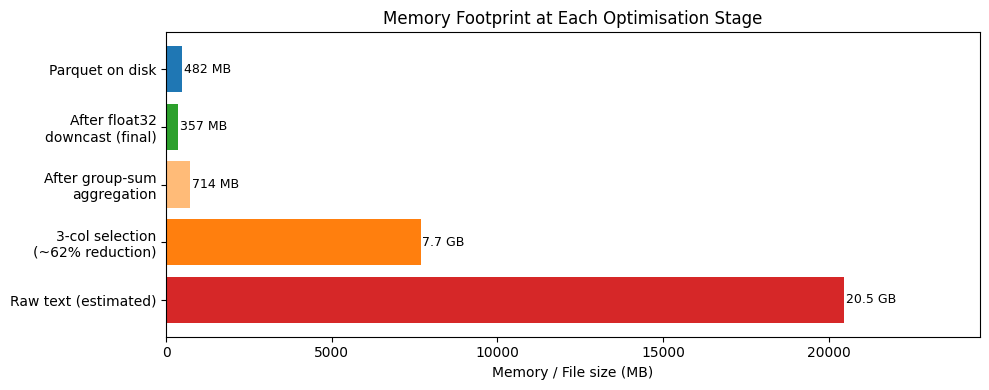

Saved figure: memory_optimisation.png


In [11]:
import matplotlib.pyplot as plt

stages = [
    ('Raw text (estimated)', total_raw_bytes / 1e6),
    ('3-col selection\n(~62% reduction)', total_raw_bytes / 1e6 * 3/8),
    ('After group-sum\naggregation', df_mem_mb(pivot) * 2),   # approx pre-float32
    ('After float32\ndowncast (final)', df_mem_mb(pivot)),
    ('Parquet on disk', pq_size / 1e6),
]

labels, values = zip(*stages)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels, values, color=['#d62728','#ff7f0e','#ffbb78','#2ca02c','#1f77b4'])
ax.set_xlabel('Memory / File size (MB)')
ax.set_title('Memory Footprint at Each Optimisation Stage')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.1f} GB' if val > 1000 else f'{val:.0f} MB',
            va='center', fontsize=9)
ax.set_xlim(0, max(values) * 1.2)
plt.tight_layout()
plt.savefig('../outputs/figures/memory_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure: memory_optimisation.png')

## 1.10 Discussion of Challenges

**Challenge 1 - Extraction not feasible**: Unzipping 5 GB -> 15 GB would temporarily require ~20 GB of free disk space during extraction. By streaming directly from zip archives using Python's `zipfile` module we avoided this entirely.

**Challenge 2 - Multiple rows per (area, time)**: Each 10-minute slot can have dozens of rows from different country codes. Forgetting to aggregate before pivoting would produce duplicate index errors or incorrect traffic values. A `groupby().sum()` per daily file, then a second deduplication pass after concat, guarantees correctness.

**Challenge 3 - RAM headroom**: Holding all 62 daily files as a single long-format DataFrame before pivoting requires ~2–3× peak RAM due to temporary copies during concat and pivot. Processing one file at a time (then concat) keeps the working set small at any moment.

**Challenge 4 - Missing time slots**: Not every (square_id, time_interval) pair appears in the raw data - areas with zero Internet activity have no record. These are correctly interpreted as zero and filled accordingly.

**Challenge 5 - Timestamp encoding**: Raw timestamps are Unix milliseconds (int64). Converting to `pd.Timestamp` and using them as the pivot index gives a proper `DatetimeIndex` for time-series operations downstream.